In [8]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

/Users/mouradderbedrosian/turtle_tracker/garmin-detect/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# frame_dir = "/Volumes/PortableSSD/tutrtletest/turtle_test_2_short/frames"
frame_dir = "/Volumes/PortableSSD/tutrtletest/turtlepond_2026-06-29_112336/frames"
num_frames = 11000
background_sample_count = 1000
frames_to_plot = 6

In [10]:
frame_fns = os.listdir(frame_dir)
frame_fns = [fn for fn in frame_fns if fn.endswith(".jpg") or fn.endswith(".png")]
frame_fns.sort()

print(len(frame_fns))
print(frame_fns)

frame_fns = frame_fns[:num_frames]

if not frame_fns:
    raise ValueError("No frames found to process")

background_sample_size = min(background_sample_count, len(frame_fns))
background_sample_indices = np.linspace(
    0, len(frame_fns) - 1, background_sample_size, dtype=int
)
background_frame_fns = [frame_fns[i] for i in background_sample_indices]
print(f"Using {len(background_frame_fns)} evenly spaced frames for background")

11305
['frame_014677_raw_rotated.png', 'frame_014678_raw_rotated.png', 'frame_014679_raw_rotated.png', 'frame_014680_raw_rotated.png', 'frame_014681_raw_rotated.png', 'frame_014682_raw_rotated.png', 'frame_014683_raw_rotated.png', 'frame_014684_raw_rotated.png', 'frame_014685_raw_rotated.png', 'frame_014686_raw_rotated.png', 'frame_014687_raw_rotated.png', 'frame_014688_raw_rotated.png', 'frame_014689_raw_rotated.png', 'frame_014690_raw_rotated.png', 'frame_014691_raw_rotated.png', 'frame_014692_raw_rotated.png', 'frame_014693_raw_rotated.png', 'frame_014694_raw_rotated.png', 'frame_014695_raw_rotated.png', 'frame_014696_raw_rotated.png', 'frame_014697_raw_rotated.png', 'frame_014698_raw_rotated.png', 'frame_014699_raw_rotated.png', 'frame_014700_raw_rotated.png', 'frame_014701_raw_rotated.png', 'frame_014702_raw_rotated.png', 'frame_014703_raw_rotated.png', 'frame_014704_raw_rotated.png', 'frame_014705_raw_rotated.png', 'frame_014706_raw_rotated.png', 'frame_014707_raw_rotated.png', '

In [11]:
def load_frame_channel(frame_path, channel=0):
    frame = cv2.imread(frame_path)
    if frame is None:
        raise FileNotFoundError(f"Could not read frame: {frame_path}")
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    return frame[:, :, channel]


frame_sum = None
preview_frames = []

for i, frame_fn in enumerate(background_frame_fns):
    frame_path = os.path.join(frame_dir, frame_fn)
    print(frame_path)
    frame = load_frame_channel(frame_path)

    if frame_sum is None:
        frame_shape = frame.shape
        frame_sum = np.zeros(frame_shape, dtype=np.float64)
    elif frame.shape != frame_shape:
        raise ValueError(
            f"Frame shape changed at {frame_path}: {frame.shape} != {frame_shape}"
        )

    frame_sum += frame
    if i < frames_to_plot:
        preview_frames.append(frame.copy())

if frame_sum is None:
    raise ValueError("No frames found to process")


/Volumes/PortableSSD/tutrtletest/turtlepond_2026-06-29_112336/frames/frame_014677_raw_rotated.png
/Volumes/PortableSSD/tutrtletest/turtlepond_2026-06-29_112336/frames/frame_014688_raw_rotated.png
/Volumes/PortableSSD/tutrtletest/turtlepond_2026-06-29_112336/frames/frame_014699_raw_rotated.png
/Volumes/PortableSSD/tutrtletest/turtlepond_2026-06-29_112336/frames/frame_014710_raw_rotated.png
/Volumes/PortableSSD/tutrtletest/turtlepond_2026-06-29_112336/frames/frame_014721_raw_rotated.png
/Volumes/PortableSSD/tutrtletest/turtlepond_2026-06-29_112336/frames/frame_014732_raw_rotated.png
/Volumes/PortableSSD/tutrtletest/turtlepond_2026-06-29_112336/frames/frame_014743_raw_rotated.png
/Volumes/PortableSSD/tutrtletest/turtlepond_2026-06-29_112336/frames/frame_014754_raw_rotated.png
/Volumes/PortableSSD/tutrtletest/turtlepond_2026-06-29_112336/frames/frame_014765_raw_rotated.png
/Volumes/PortableSSD/tutrtletest/turtlepond_2026-06-29_112336/frames/frame_014776_raw_rotated.png
/Volumes/PortableSSD

11000 1000 (512, 511)
<class 'numpy.ndarray'> (512, 511) -102.558 114.79
<class 'numpy.ndarray'> (512, 511) -114.623 103.894
<class 'numpy.ndarray'> (512, 511) -115.037994 97.866
<class 'numpy.ndarray'> (512, 511) -142.822 95.721
<class 'numpy.ndarray'> (512, 511) -126.08501 100.038
<class 'numpy.ndarray'> (512, 511) -107.041 98.283


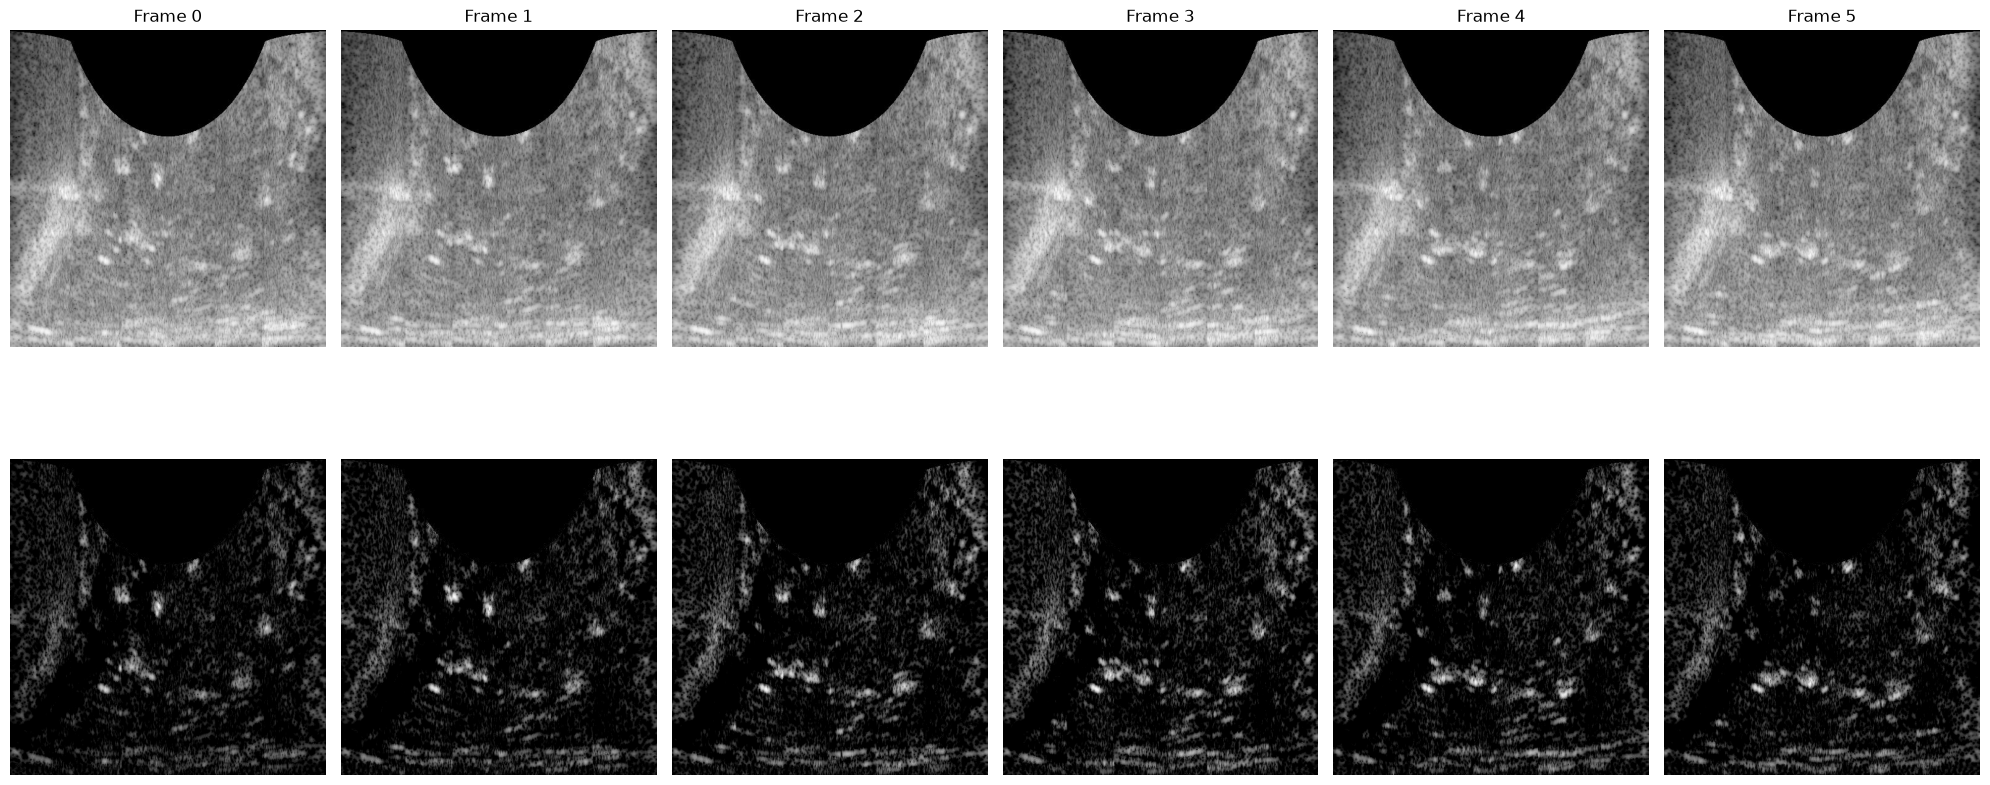

In [12]:
print(len(frame_fns), len(background_frame_fns), frame_shape)

frames_averaged = (frame_sum / len(background_frame_fns)).astype(np.float32)
del frame_sum
# A percentile background still requires retaining many frames in memory.
# frames_averaged = np.percentile(frames, 25, axis=0)

display_count = min(frames_to_plot, len(preview_frames))
fig, ax = plt.subplots(2, display_count, figsize=(20, 10))
if display_count == 1:
    ax = np.array(ax).reshape(2, 1)

for i, frame in enumerate(preview_frames[:display_count]):
    ax[0, i].imshow(frame, cmap="gray")
    ax[0, i].set_title(f"Frame {i}")
    ax[0, i].axis("off")

    frame_bgs = frame.astype(np.float32) - frames_averaged
    print(type(frame_bgs), frame_bgs.shape, np.min(frame_bgs), np.max(frame_bgs))
    frame_bgs = np.clip(frame_bgs, 0, 255)
    ax[1, i].imshow(frame_bgs, cmap="gray")
    ax[1, i].axis("off")

plt.tight_layout()
plt.show()


In [13]:
# Keep only small preview arrays in memory. The full background-subtracted
# sequence is generated one frame at a time in the echogram cell below.
out_dir = "gifs"
os.makedirs(out_dir, exist_ok=True)

orig_frames = np.array(preview_frames[:frames_to_plot], dtype=np.uint8)


Generating echogram: 100%|██████████| 11000/11000 [00:42<00:00, 258.41it/s]


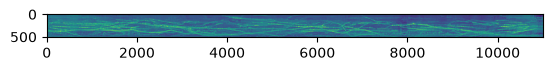

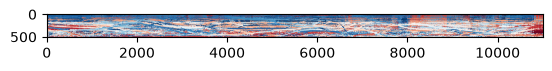

(512, 11000) 0 133
(512, 11000, 3) 0.0 0.9700115340253749


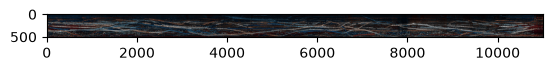

In [ ]:
echogram = np.zeros((frame_shape[0], len(frame_fns), 2), dtype=np.uint8)

for i, frame_fn in enumerate(tqdm(frame_fns, desc="Generating echogram")):
    frame_path = os.path.join(frame_dir, frame_fn)
    frame = load_frame_channel(frame_path).astype(np.float32)
    bgs_frame = frame - frames_averaged
    bgs_frame = np.clip(bgs_frame, 0, 255) / 255

    echogram_brightness = np.max(bgs_frame, axis=1)
    echogram_angle = np.argmax(bgs_frame, axis=1) / bgs_frame.shape[1]

    echogram[:, i, 0] = echogram_brightness * 255
    echogram[:, i, 1] = echogram_angle * 255
    del frame, bgs_frame

plt.imshow(echogram[:, :, 0])
plt.show()
plt.imshow(echogram[:, :, 1], cmap="RdBu")
plt.show()


angle_colour = echogram[:, :, 1]/255
# print("A", angle_colour.shape, np.min(angle_colour), np.max(angle_colour))

# angle_colour = (2 * (angle_colour-0.5))
# print("B", angle_colour.shape, np.min(angle_colour), np.max(angle_colour))

# angle_colour= (angle_colour) ** 0.5
# print("C", angle_colour.shape, np.min(angle_colour), np.max(angle_colour))

# angle_colour = (angle_colour+1)/2
# print("D", angle_colour.shape, np.min(angle_colour), np.max(angle_colour))

angle_colour = plt.get_cmap("RdBu")(angle_colour)[:, :, :3]
brightness = (echogram[:, :, 0, None] / 255)

brightness /= np.max(brightness)
brightness = brightness ** 1.5
angle_colour = angle_colour * brightness
plt.imshow(angle_colour)
plt.show()
# save echogram as a PNG
echogram_out_path = os.path.join(out_dir, "echogram.png")
plt.imsave(echogram_out_path, angle_colour)
